# Charts

In [1]:
import os
import sys

import pandas as pd
import polars as pl
from catboost import CatBoostRegressor

os.chdir("../../")
sys.path.insert(0, os.getcwd())

In [2]:
from morai.experience import charters
from morai.forecast import preprocessors
from morai.utils import custom_logger, helpers

In [3]:
# default is "plotly_mimetype+notebook", however that takes up space.
# "plotly_mimetype+notebook_connected" seems to save space
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+notebook_connected"

# Charts

## Data

In [4]:
# standard df
df = pd.DataFrame(
    {
        "attained_age": [10, 20, 30, 40, 50, 10, 20, 30, 40, 50],
        "gender": ["M", "M", "M", "M", "M", "F", "F", "F", "F", "F"],
        "actuals": [1, 2, 3, 4, 5, 1, 2, 3, 4, 5],
        "exposures": [50, 50, 50, 50, 50, 100, 100, 100, 100, 100],
    }
)

## Line

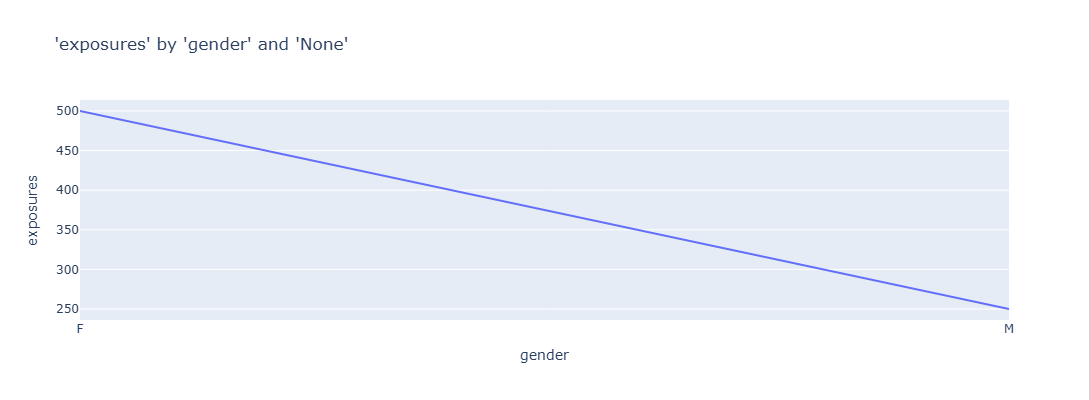

In [5]:
charters.chart(df=df, x_axis="gender", y_axis="exposures", type="line")

## Bar

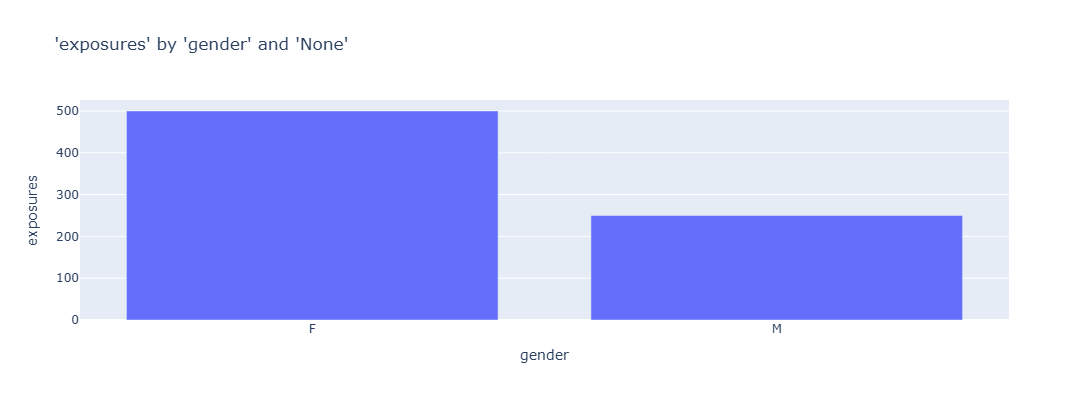

In [8]:
charters.chart(df=df, x_axis="gender", y_axis="exposures", type="bar")

## Heatmap

 2026-01-16 21:38:53 | morai.experience.charters | INFO     | Calculating ratio using [actuals] and [exposures] 


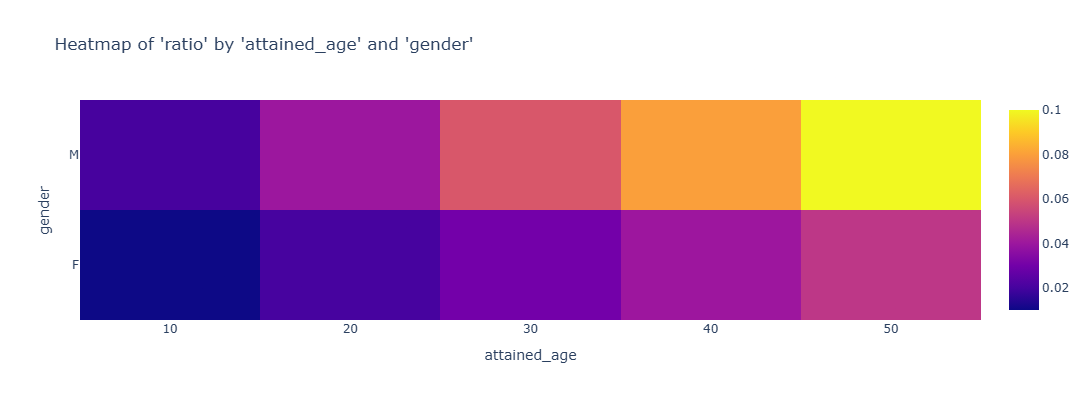

In [14]:
charters.chart(
    df=df, x_axis="attained_age", y_axis="gender", color="ratio", numerator="actuals", denominator="exposures", type="heatmap"
)

## Histogram

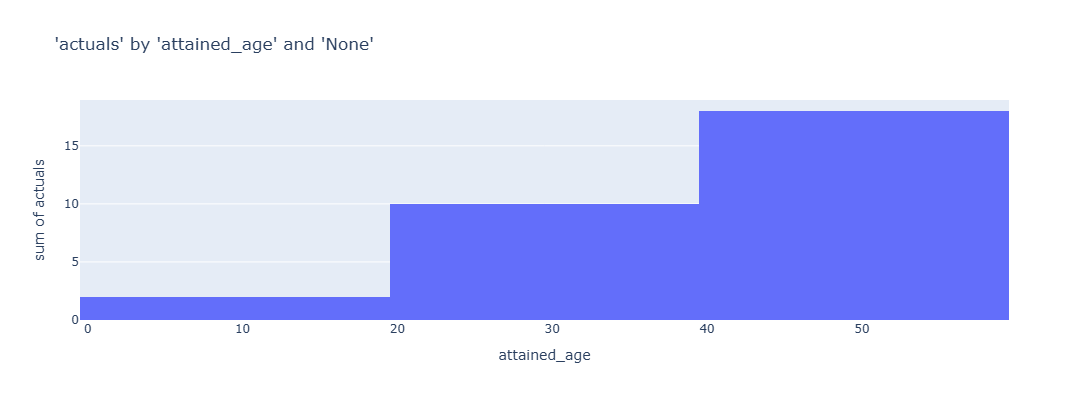

In [15]:
charters.chart(df=df, x_axis="attained_age", y_axis="actuals", type="histogram")

## Area

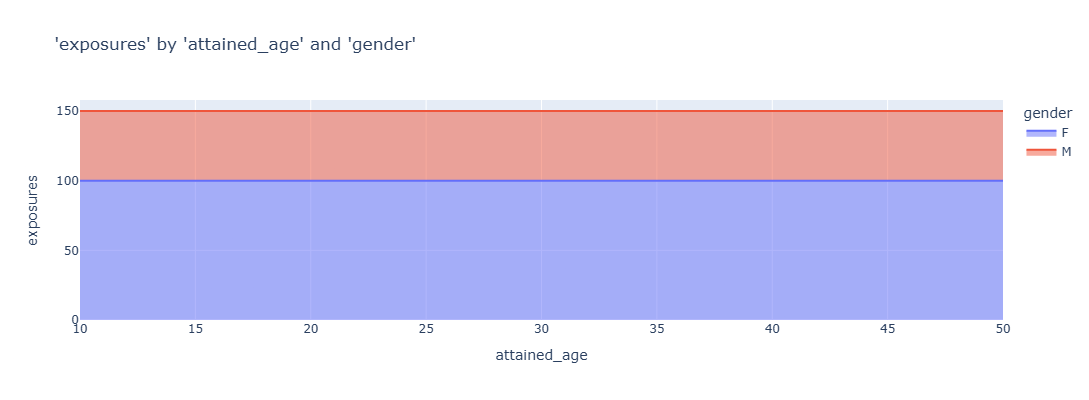

In [16]:
charters.chart(df=df, x_axis="attained_age", y_axis="exposures", color="gender", type="area")

## Contour

 2026-01-16 21:40:16 | morai.experience.charters | INFO     | Calculating ratio using [actuals] and [exposures] 


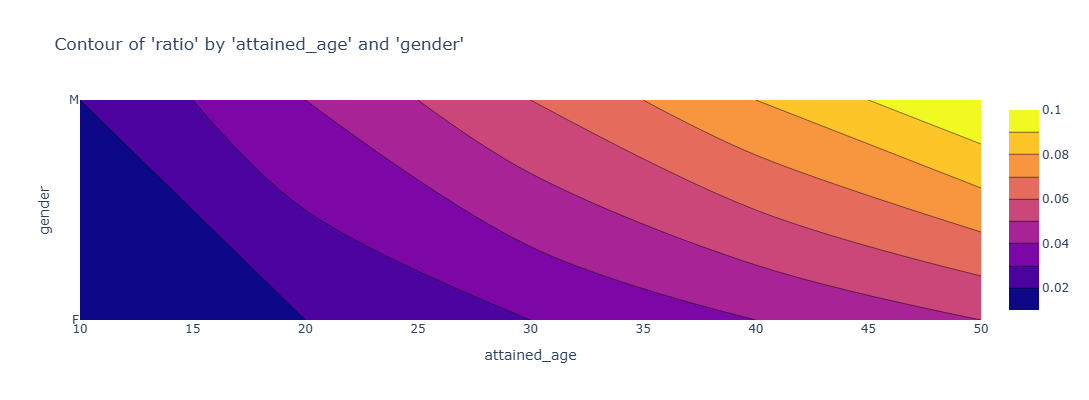

In [17]:
charters.chart(
    df=df, x_axis="attained_age", y_axis="gender", color="ratio", numerator="actuals", denominator="exposures", type="contour"
)

# PDP

This shows an example of how the Partial Dependency Plot could be used

The following shows a group of people that exercise, eat healthy, and age.The actual relationships are as follows:
- every 10 years the rate goes up by 10% starting at .01
- unhealthy has 50% higher rate than healthy
- non-exercise has 2% higher rate than exercise
- exercise and healthy are highly correlated as almost everyone does both or either but rarely does one or the either.

When looking at the data, a user may say that exercise is highly predictive of the rate. This would be false as there are some people that exercise and do not eat healthy and their rate is much higher than the people that eat healthy. **PDP woul capture this relationship**. A **pairwise** plot would also capture this relationship.

## Data

In [23]:
pdp_data = pd.read_csv("tests/files/experience/charters/pdp_example.csv")
feature_dict = {
    "target": ["rate"],
    "weight": ["weight"],
    "ordinal": ["age", "healthy", "exercise"],
}
preprocess_dict = preprocessors.preprocess_data(
    pdp_data,
    feature_dict=feature_dict,
    standardize=False,
    preset="pass",
)
X = preprocess_dict["X"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]
mapping = preprocess_dict["mapping"]
md_encoded = preprocess_dict["md_encoded"]
model_features = preprocess_dict["model_features"]

 2025-08-03 23:11:08 | morai.forecast.preprocessors | INFO     | using 'pass' preset which makes all features passthrough 
 2025-08-03 23:11:08 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-08-03 23:11:08 | morai.forecast.preprocessors | INFO     | model weights: ['weight'] 
 2025-08-03 23:11:08 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['exercise', 'age', 'healthy'] 


## Comparison

In [24]:
cat_features = feature_dict["ordinal"]
cat_features = list(set(cat_features) & set(model_features))

In [25]:
model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.05,
    depth=8,
    cat_features=cat_features,
    one_hot_max_size=11,
)
model.fit(X, y, sample_weight=weights, verbose=0)

In [26]:
pdp_data["pred"] = model.predict(X)

In [42]:
pdp_data["rate_weight"] = pdp_data["rate"] * pdp_data["weight"]

## Chart

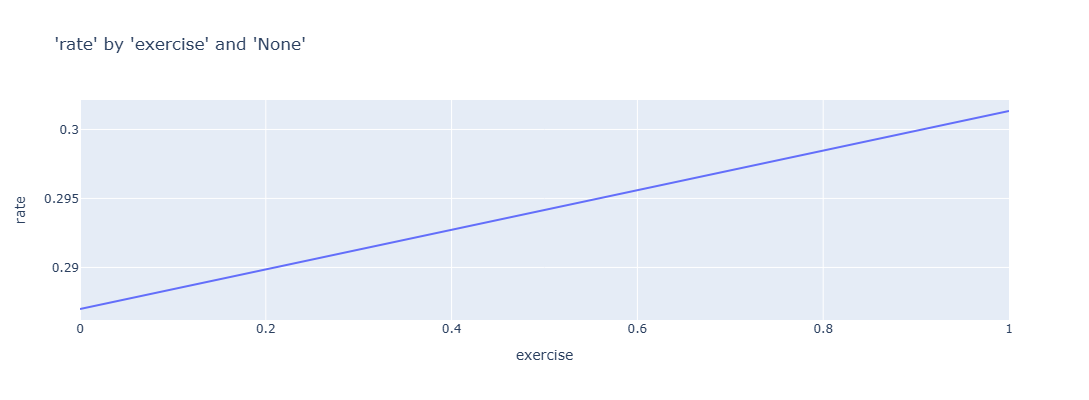

In [22]:
charters.chart(
    df=pdp_data,
    x_axis="exercise",
    y_axis="rate",
)

 2025-08-03 23:21:13 | morai.experience.charters | INFO     | Creating '4' target plots. 


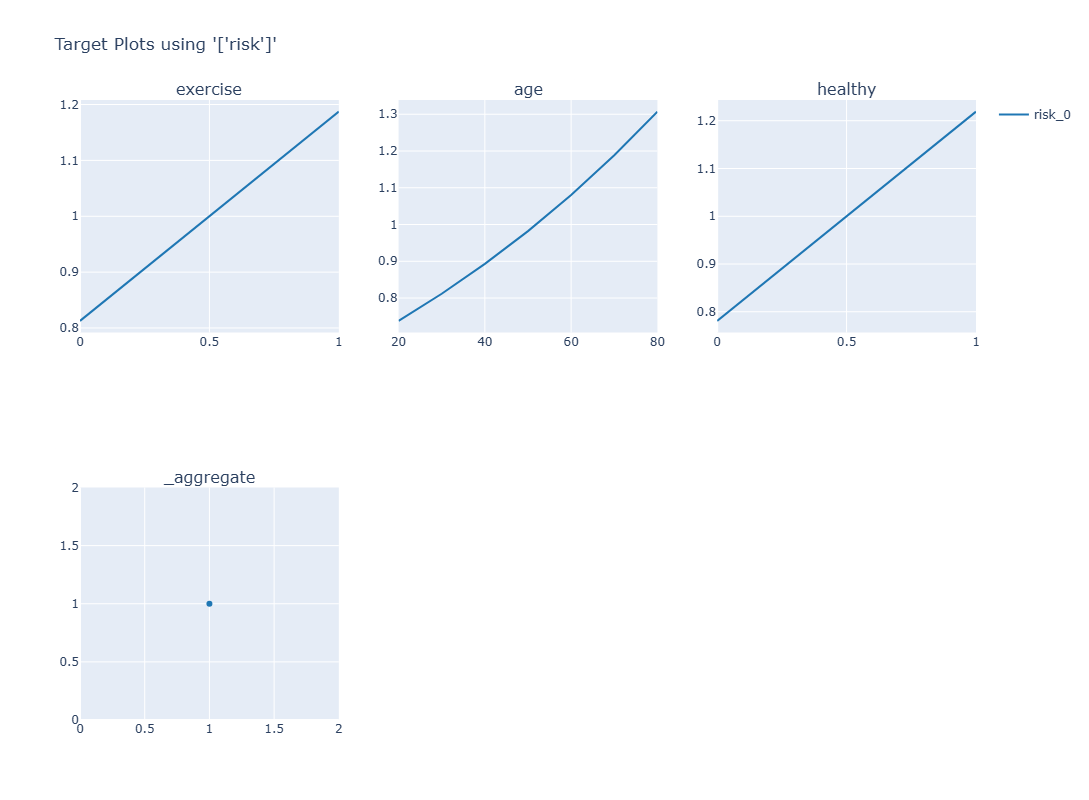

In [47]:
charters.target(
    df=pdp_data,
    target="risk",
    features=["exercise", "age", "healthy"],
    numerator=["rate_weight"],
    denominator=["weight"],
)

 2025-08-03 23:21:48 | morai.experience.charters | INFO     | Model: [CatBoostRegressor] for partial dependence plot. 
 2025-08-03 23:21:48 | morai.experience.charters | INFO     | Weights: [weight] 
 2025-08-03 23:21:48 | morai.experience.charters | INFO     | x_axis: [age] type: [passthrough] center: [global] 
 2025-08-03 23:21:48 | morai.experience.charters | INFO     | Creating 7 predictions. 


Processing:   0%|          | 0/7 [00:00<?, ?combo/s]

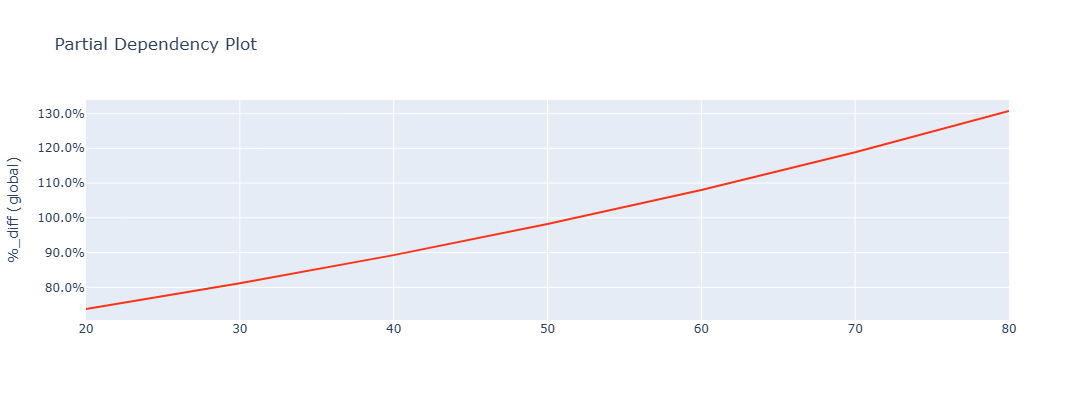

In [48]:
charters.pdp(
    model=model,
    df=md_encoded,
    x_axis="age",
    weight="weight",
    mapping=mapping,
    display=True,
)

 2025-08-03 23:22:03 | morai.experience.charters | INFO     | Model: [CatBoostRegressor] for partial dependence plot. 
 2025-08-03 23:22:03 | morai.experience.charters | INFO     | Weights: [weight] 
 2025-08-03 23:22:03 | morai.experience.charters | INFO     | x_axis: [exercise] type: [passthrough] center: [global] 
 2025-08-03 23:22:03 | morai.experience.charters | INFO     | Creating 2 predictions. 


Processing:   0%|          | 0/2 [00:00<?, ?combo/s]

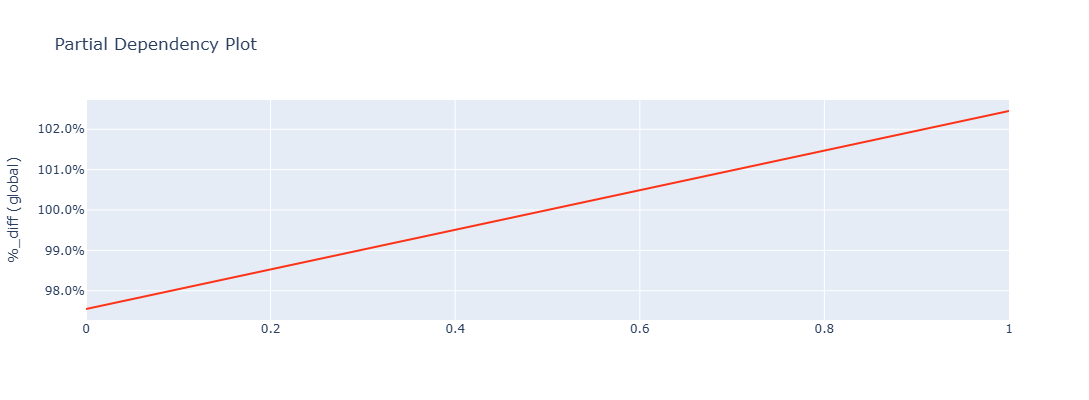

In [49]:
charters.pdp(
    model=model,
    df=md_encoded,
    x_axis="exercise",
    weight="weight",
    mapping=mapping,
    display=True,
)

 2025-08-03 23:22:19 | morai.experience.charters | INFO     | Model: [CatBoostRegressor] for partial dependence plot. 
 2025-08-03 23:22:19 | morai.experience.charters | INFO     | Weights: [weight] 
 2025-08-03 23:22:19 | morai.experience.charters | INFO     | x_axis: [healthy] type: [passthrough] center: [global] 
 2025-08-03 23:22:19 | morai.experience.charters | INFO     | Creating 2 predictions. 


Processing:   0%|          | 0/2 [00:00<?, ?combo/s]

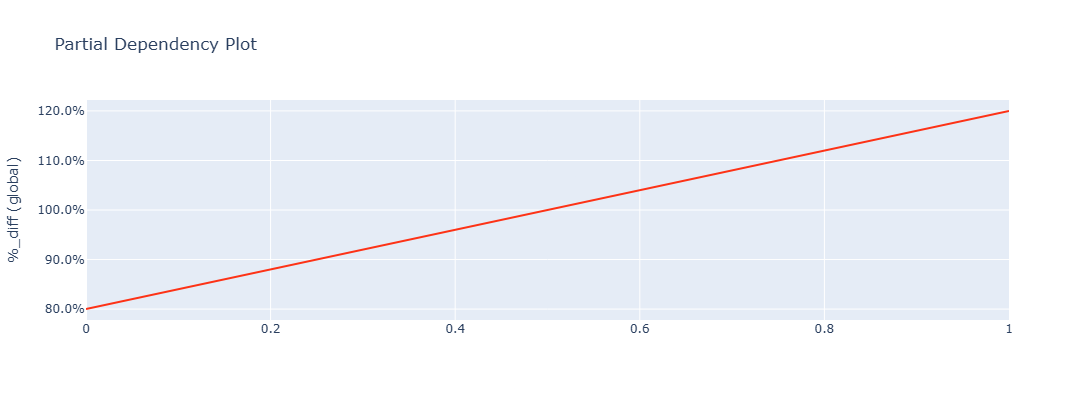

In [50]:
charters.pdp(
    model=model,
    df=md_encoded,
    x_axis="healthy",
    weight="weight",
    mapping=mapping,
    display=True,
)

 2025-08-03 23:32:28 | morai.experience.charters | INFO     | Generating `1` pairwise plots from features 
 2025-08-03 23:32:28 | morai.experience.charters | INFO     | Creating '1' pairwise plots. 


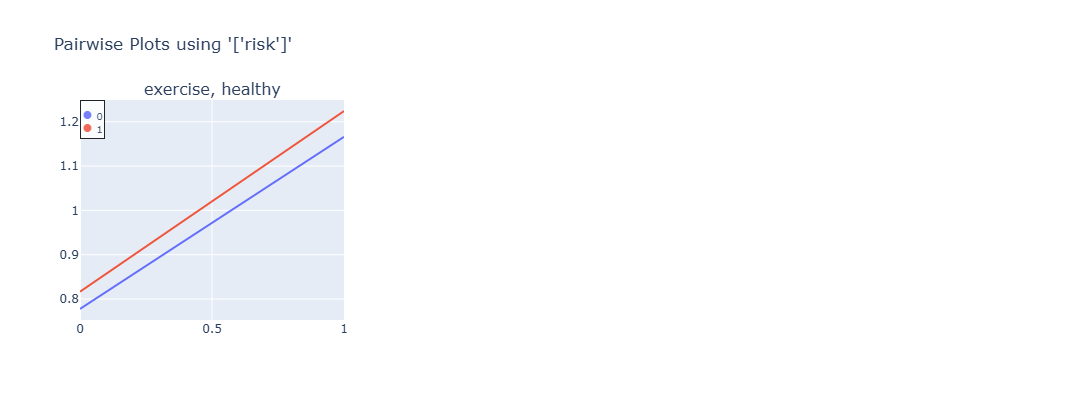

In [53]:
charters.target(
    df=pdp_data,
    target="risk",
    features=["exercise", "healthy"],
    numerator=["rate_weight"],
    denominator=["weight"],
    generate_pairwise=True,
)